In [10]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt


In [6]:
print(sklearn.__version__, pd.__version__)

1.8.0 3.0.3


In [8]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
                31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
                34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
                38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0,
                500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0,
                610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0,
                714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2,
                12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2,
                13.4, 12.2, 19.7, 19.9]

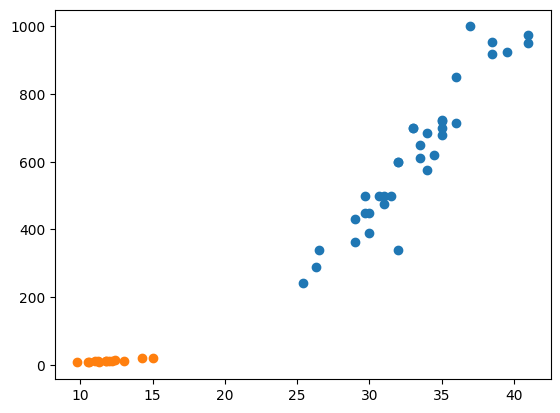

In [12]:
plt.scatter(bream_length,bream_weight)
plt.scatter(smelt_length,smelt_weight)

In [ ]:
#데이터 전처리

length = bream_length + smelt_length
weight = bream_weight + smelt_weight

In [ ]:
#feature 특성 정보를 묶었음. 길이, 무게
fish_data =[[l,w] for l, w in zip(length, weight)]
fish_data[0:5]

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]

In [15]:
# label 정답 정보
fish_target =[1] * 35 +[0] * 14 
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [16]:
# 데이터 쪼개기
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, \
train_target, test_target = train_test_split(
    fish_data,
    fish_target,
    random_state=42   # 재현성
    )
print(len(train_input))  # 36
print(len(test_input))   # 13

36
13


- train set : 모델이 학습하는 데이터
test set : 모델이 보지 못하는 데이터 (평가할 때만 사용)
random

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
kn = KNeighborsClassifier()
kn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
from sklearn.neighbors import KNeighborsClassifier
# 1. 모델 생성
kn = KNeighborsClassifier()  # 기본 k=5
# 2. 학습 (데이터 저장)
kn.fit(fish_data, fish_target)
# 3. 예측
result = kn.predict([[30, 600]])
print(result)   # [1] → 도미
# 4. 정확도
score = kn.score(fish_data, fish_target)
print(score)    
# 1.0

[1]
1.0


In [22]:
train_X, test_X, train_y, test_y = \
train_test_split(fish_data, fish_target,
random_state=42)
kn.fit(train_X, train_y)
print("훈련:", kn.score(train_X, train_y))
print("테스트:", kn.score(test_X, test_y))

훈련: 1.0
테스트: 1.0


In [24]:
for k in [1, 3, 5, 10, 49]:
    kn_k = KNeighborsClassifier(n_neighbors=k)
    kn_k.fit(fish_data, fish_target)
    score = kn_k.score(fish_data, fish_target)
    print(f"k={k:2d}: {score:.4f}")

k= 1: 1.0000
k= 3: 1.0000
k= 5: 1.0000
k=10: 1.0000
k=49: 0.7143


In [27]:
## 샘플링
# 학습데이터와 테스트 데이터를 어떻게 나누는가?  조건이라도 있나?
# 샘플링 편향 (Sampling bias)

# numpy 와 knn 데이터 섞기
# 브로드 캐스팅 : 사칙 연산을 모든 행이나 모든 열로 확장해서 수행하는 기능
import numpy as np
print(len(fish_data * 100))
fish_ndarr = np.array(fish_data)
fish_ndarr = np.array(fish_data)
print(len(fish_ndarr * 100))

4900
49


## 스케일링
- 스케일, 표준화
- 스케일이 다른 특성은 어떻게 처리하는가?
